# 엑셀 자동화 

In [2]:
# !pip install pandas 
# !pip install seaborn

In [1]:
# !pip install pandas     # 설치

In [5]:
import pandas as pd

## Pandas DataFrame

In [6]:
emp={
    '사원번호' : ['001', '002', '003', '004', '005'],
    '사원명' : ['채치수', '정대만', '송태섭', '서태웅', '강백호'],
    '직급' : ['사원', '사원', '주임', '주임', '선임']
}

In [7]:
emp_df=pd.DataFrame(emp)
emp_df

,사원번호,사원명,직급
0,001,채치수,사원
1,002,정대만,사원
2,003,송태섭,주임
3,004,서태웅,주임
4,005,강백호,선임


In [10]:
emp_df.columns.tolist()          # list(emp_df.columns)

['사원번호', '사원명', '직급']

In [11]:
emp_df.index.tolist()            # list(emp_df.index)

[0, 1, 2, 3, 4]

## 엑셀 저장 및 불러오기

In [12]:
emp_df.to_excel('./결과/데이터프레임/emp.xlsx', index=False)

In [13]:
new_emp=pd.read_excel('./결과/데이터프레임/emp.xlsx')
new_emp

,사원번호,사원명,직급
0,1,채치수,사원
1,2,정대만,사원
2,3,송태섭,주임
3,4,서태웅,주임
4,5,강백호,선임


## 질문법을 통한 편집

In [13]:
df=pd.read_excel("./결과/웹/naver_cafe_elect01.xlsx")

- [프롬프트]
    - df라는 변수에 판다스 데이터프레임이 저장되어 있어. 컬럼명과 인덱스 정보를 확인하고, 파이썬 리스트 형태로 출력하는 코드를 작성해줘.

In [16]:
print("컬럼명:", df.columns.tolist())
print("인덱스:", df.index)

컬럼명: ['키워드', '게시글제목', 'URL']
인덱스: RangeIndex(start=0, stop=154, step=1)


- [프롬프트]
    - 위의 내용을 참조하여, 아래의 기본 정보를 파악하는 코드를 작성해줘
        - 행/열 개수
        - 데이터 타입
        - 결측치
        - 고유값 개수
        - 중복 데이터
        - 앞/뒤 데이터
        - 기초 통계량

In [19]:
# 행/열 개수
print("행/열 개수:", df.shape)

# 데이터 타입
print("\n[데이터 타입]")
print(df.dtypes)

# 결측치 개수
print("\n[결측치]")
print(df.isnull().sum())

# 고유값 개수
print("\n[고유값 개수]")
print(df.nunique())

# 중복 데이터 개수
print("\n[중복 데이터 개수]")
print(df.duplicated().sum())

# 앞쪽 데이터 5개
print("\n[앞쪽 데이터]")
print(df.head())

# 뒤쪽 데이터 5개
print("\n[뒤쪽 데이터]")
print(df.tail())

# 기초 통계량
print("\n[기초 통계량]")
print(df.describe())

행/열 개수: (154, 3)

[데이터 타입]
키워드      str
게시글제목    str
URL      str
dtype: object

[결측치]
키워드      0
게시글제목    0
URL      0
dtype: int64

[고유값 개수]
키워드        5
게시글제목    152
URL      154
dtype: int64

[중복 데이터 개수]
0

[앞쪽 데이터]
   키워드                         게시글제목  \
0  에어컨  에어컨렌탈 지원 많은곳! 당일지급 전국접수 빠른설치   
1  에어컨       시스템 에어컨은 송풍 시 원래 냄새나나요?   
2  에어컨               시스템 에어컨 냉기가 약해요   
3  에어컨      에어컨 킨다고 냉장고가 나가는 집이 있나여?   
4  에어컨          시스템에어컨 쓰시는분 만족하시나요??   

                                                 URL  
0  https://ader.naver.com/v1/2aBzPzuZnfVeLYj_1_9a...  
1  https://cafe.naver.com/skybluezw4rh/14763296?a...  
2  https://cafe.naver.com/dongtantwomom/2536472?a...  
3  https://cafe.naver.com/cafe1535/1862444?art=ZX...  
4  https://cafe.naver.com/isajime/6068592?art=ZXh...  

[뒤쪽 데이터]
       키워드                                              게시글제목  \
149  서큘레이터  종료))네이버) 루메나 무선 써큘레이터 FAN PRIME 3 34,900(넾다쿠폰 ...   
150  서큘레이터               BLDC 서큘레이터 선풍기 써보니 일반 선풍기와 다른점 비교 후기   
151 

- [프롬프트]
    - df라는 데이터 프레임의 컬럼명은 키워드, 게시글제목 , URL 구성 되어 있어. 키워드별 게시글 수 집계하는 코드 작성해줘

In [18]:
# 키워드별 게시글 수 집계
keyword_count = (
    df.groupby("키워드")
      .size()
      .reset_index(name="게시글수")
)

# 게시글 수 내림차순 정렬
keyword_count = keyword_count.sort_values(
    by="게시글수",
    ascending=False
)

display(keyword_count)

,키워드,게시글수
4,제습기,32
3,에어컨,31
2,선풍기,31
0,냉풍기,30
1,서큘레이터,30


- [프롬프트]
    - 위 내용을 기반으로 시각화 코드 작성해줘
    - [한글이 깨지면] 그래프 한글이 깨짐

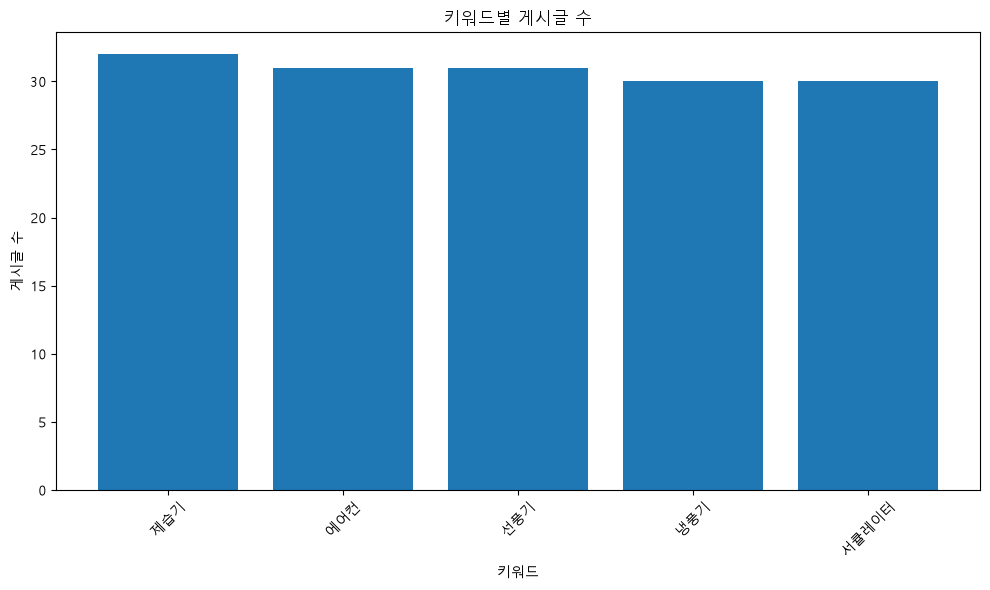

In [23]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 키워드별 게시글 수 집계
result = df["키워드"].value_counts().reset_index()
result.columns = ["키워드", "게시글수"]

# 막대그래프
plt.figure(figsize=(10, 6))
plt.bar(result["키워드"], result["게시글수"])

plt.title("키워드별 게시글 수")
plt.xlabel("키워드")
plt.ylabel("게시글 수")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- [프롬프트]
    - 위의 내용을 참조하여 더 다양한 그래프 작성해줘

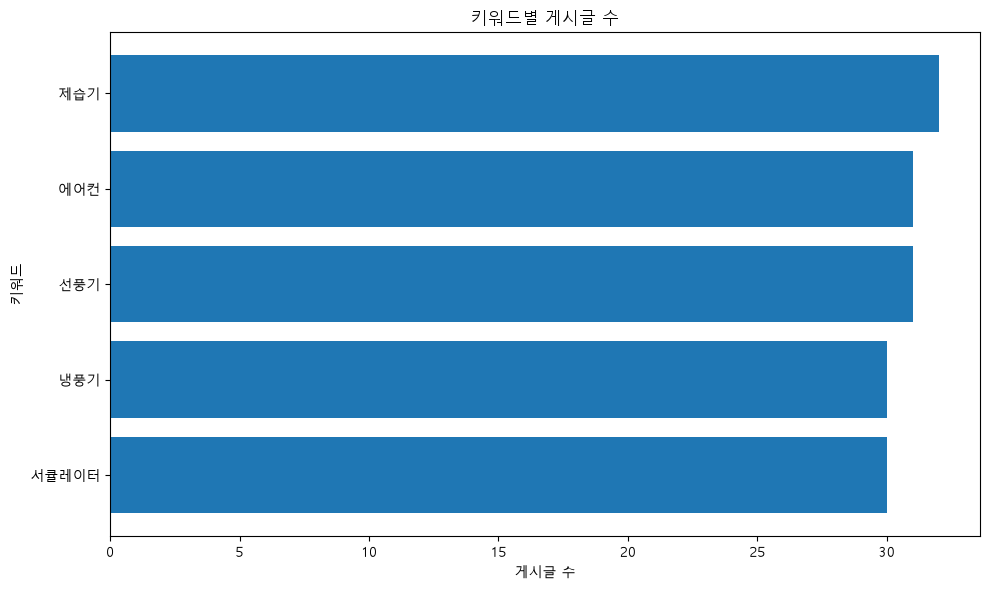

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(result["키워드"], result["게시글수"])

plt.title("키워드별 게시글 수")
plt.xlabel("게시글 수")
plt.ylabel("키워드")

# 많은 키워드가 위로 오도록
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

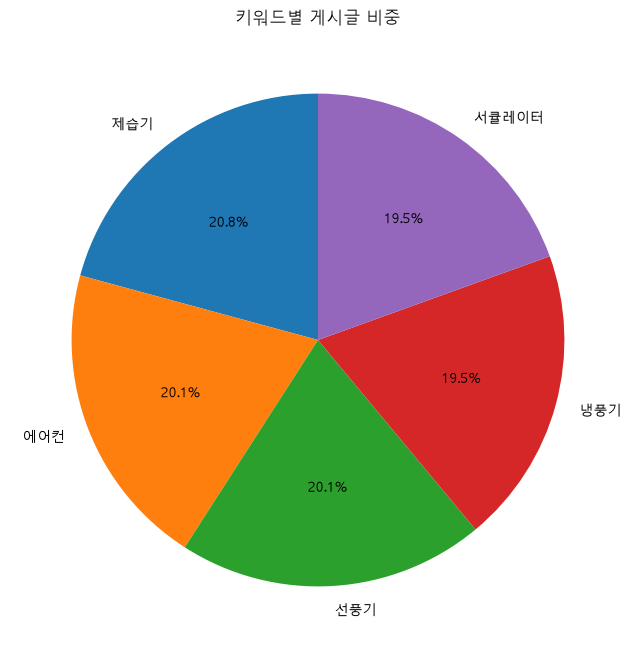

In [26]:
plt.figure(figsize=(8, 8))

plt.pie(
    result["게시글수"],
    labels=result["키워드"],
    autopct="%.1f%%",
    startangle=90
)

plt.title("키워드별 게시글 비중")

plt.show()

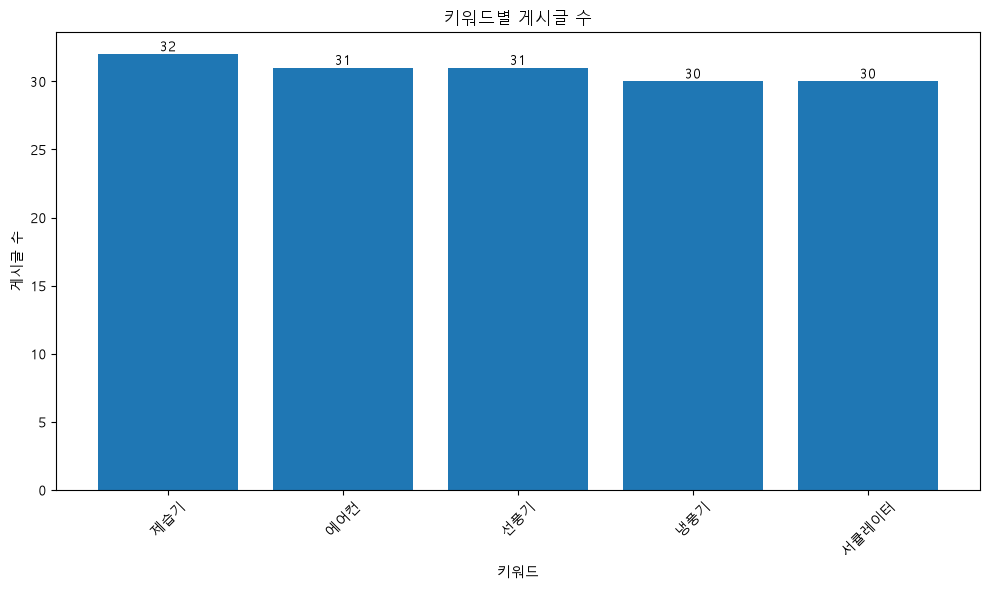

In [27]:
plt.figure(figsize=(10, 6))

bars = plt.bar(result["키워드"], result["게시글수"])

plt.title("키워드별 게시글 수")
plt.xlabel("키워드")
plt.ylabel("게시글 수")
plt.xticks(rotation=45)

# 막대 위에 게시글 수 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# 외부 라이브러리 활용
- [프롬프트]
    - 파이썬에서 지도를 시각화하거나 다룰 때 사용하는 대표적인 외부 라이브러리인 추천해주고 설치 방법 알려줘

In [ ]:
# !pip install folium
# !pip install folium geopy pandas

In [18]:
import folium
from folium import Figure

fig = Figure(width="800px", height="400px")    # 사이즈 줄이기 1)

m = folium.Map(
    location=[37.5665, 126.9780],
    zoom_start=12
)

fig.add_child(m)                              # 사이즈 줄이기 2)

folium.Marker(
    [37.5665, 126.9780],
    popup="서울시청"
).add_to(m)

fig                                          # 사이즈 줄이기 2)

- [프롬프트] 
    - folium를 통해서 서울시청 근처에서 평점이 높고 대중적인 식당들을 지도에서 추천해 줘. 
    - 특히 점심시간에 이용하기 좋은 곳들 위주로 보여주고, 각 장소의 대략적인 도보 이동 시간도 함께 알려줘

In [16]:
import folium
from folium import Figure

# --------------------------------
# 0. Figure를 사용해 전체 출력 크기 고정 (흰색 여백 제거)
# --------------------------------
fig = Figure(width="800px", height="400px")    

# --------------------------------
# 1. 서울시청 위치 및 지도 생성 (Figure에 추가)
# --------------------------------
city_hall = [37.5663, 126.9779]

m = folium.Map(
    location=city_hall,
    zoom_start=16, 
    width="100%",
    height="100%"
)

# 지도를 Figure에 도장 찍듯이 추가
fig.add_child(m)

# --------------------------------
# 2. 서울시청 표시
# --------------------------------
folium.Marker(
    city_hall,
    popup="<b>서울시청</b>",
    tooltip="출발지: 서울시청",
    icon=folium.Icon(color="blue", icon="home")
).add_to(m)


# --------------------------------
# 3. 추천 식당 데이터
# --------------------------------
restaurants = [
    {
        "name": "진진만두 시청점",
        "lat": 37.5667,
        "lon": 126.9792,
        "rating": 4.9,
        "reviews": 606,
        "walk": "약 2~3분",
        "menu": "만두 / 한식",
        "price": "약 1~2만원"
    },
    {
        "name": "왕비집 시청무교점",
        "lat": 37.5669,
        "lon": 126.9788,
        "rating": 4.7,
        "reviews": 1226,
        "walk": "약 2~3분",
        "menu": "고기구이 / 한식",
        "price": "약 2~7만원"
    },
    {
        "name": "장인라면 서울시청점",
        "lat": 37.5665,
        "lon": 126.9787,
        "rating": 4.3,
        "reviews": 113,
        "walk": "약 2분",
        "menu": "라면 / 김밥",
        "price": "1만원 이하"
    },
    {
        "name": "디라이프스타일키친 광화문점",
        "lat": 37.5700,
        "lon": 126.9770,
        "rating": 4.5,
        "reviews": 515,
        "walk": "약 5~7분",
        "menu": "양식 / 다양한 메뉴",
        "price": "약 2~7만원"
    },
    {
        "name": "무교동 북어국집",
        "lat": 37.5685,
        "lon": 126.9794,
        "rating": 4.5,
        "reviews": 500,
        "walk": "약 4~5분",
        "menu": "북어해장국",
        "price": "약 1만원"
    }
]


# --------------------------------
# 4. 식당 마커 추가
# --------------------------------
for r in restaurants:

    popup_html = f"""
    <div style="width:220px">
        <h4>{r['name']}</h4>
        <b>⭐ 평점:</b> {r['rating']}<br>
        <b>👥 리뷰:</b> {r['reviews']:,}개<br>
        <b>🍽 메뉴:</b> {r['menu']}<br>
        <b>💰 가격:</b> {r['price']}<br>
        <b>🚶 도보:</b> {r['walk']}
    </div>
    """

    folium.Marker(
        [r["lat"], r["lon"]],
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{r['name']} ⭐ {r['rating']}",
        icon=folium.Icon(
            color="red",
            icon="cutlery"
        )
    ).add_to(m)


# --------------------------------
# 5. 지도 출력 (마지막 줄에 fig 변수 입력)
# --------------------------------
fig

In [1]:
# End Of -------------------------------------------------------